### Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Loading excel file

In [2]:
file_path = "AI_Productivity_Project.xlsx"  # change this

tasks = pd.read_excel(file_path, sheet_name="Tasks")
employees = pd.read_excel(file_path, sheet_name="Employees")
ai_usage = pd.read_excel(file_path, sheet_name="AI_Usage")
ai_cost = pd.read_excel(file_path, sheet_name="AI_Cost_Summary")

### Basic Cleaning

In [3]:
tasks.columns = tasks.columns.str.strip().str.lower()
employees.columns = employees.columns.str.strip().str.lower()
ai_usage.columns = ai_usage.columns.str.strip().str.lower()
ai_cost.columns = ai_cost.columns.str.strip().str.lower()

In [4]:
# Converting  AI column to consistent format
tasks['ai_used'] = tasks['ai_used'].str.strip()

# Convert month to string (if needed)
tasks['month'] = tasks['month'].astype(str)
ai_cost['month'] = ai_cost['month'].astype(str)

### Kpi calculations


In [5]:
total_tasks = tasks['task_id'].count()

avg_actual_time = tasks['actual_time_min'].mean()
avg_estimated_time = tasks['estimated_time_min'].mean()

time_saved = avg_estimated_time - avg_actual_time

ai_tasks = tasks[tasks['ai_used'] == 'Yes']['task_id'].count()
ai_usage_percent = (ai_tasks / total_tasks) * 100

avg_quality = tasks['quality_score'].mean()

total_ai_cost = ai_cost['total_cost'].sum()

cost_per_task = total_ai_cost / total_tasks

print("Total Tasks:", total_tasks)
print("Avg Actual Time:", avg_actual_time)
print("Time Saved:", time_saved)
print("AI Usage %:", ai_usage_percent)
print("Avg Quality:", avg_quality)
print("Total AI Cost:", total_ai_cost)
print("Cost per Task:", cost_per_task)

Total Tasks: 1500
Avg Actual Time: 119.12266666666666
Time Saved: 15.38466666666666
AI Usage %: 61.8
Avg Quality: 7.476666666666667
Total AI Cost: 236000
Cost per Task: 157.33333333333334


### AI vs NON-AI COMPARISON

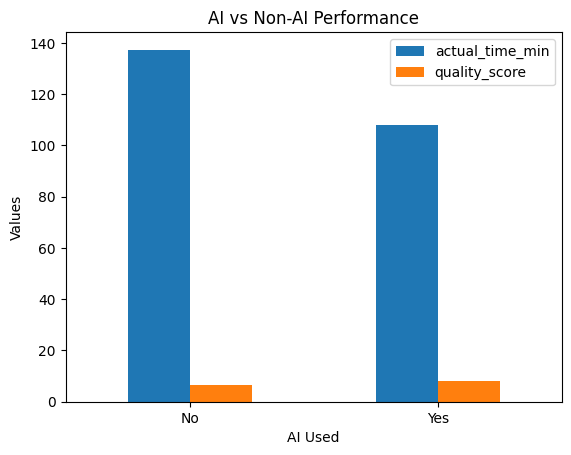

In [6]:
ai_group = tasks.groupby('ai_used').agg({
    'actual_time_min': 'mean',
    'quality_score': 'mean'
})

ai_group.plot(kind='bar')
plt.title("AI vs Non-AI Performance")
plt.xlabel("AI Used")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.show()

### TASK TYPE ANALYSIS

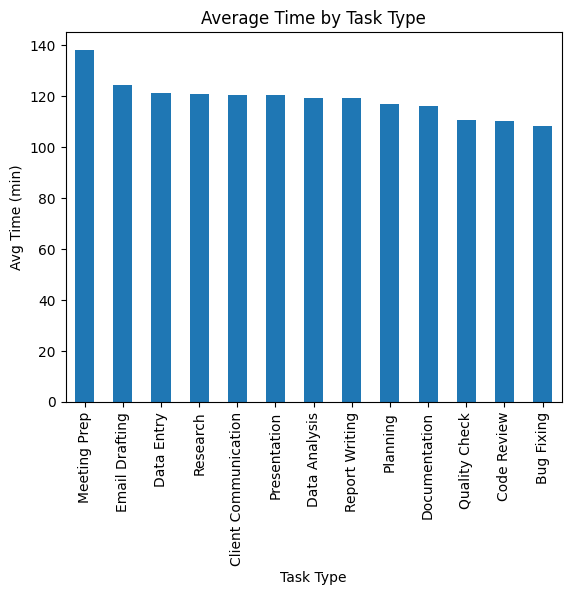

In [7]:
task_analysis = tasks.groupby('task_type')['actual_time_min'].mean().sort_values(ascending=False)

task_analysis.plot(kind='bar')
plt.title("Average Time by Task Type")
plt.xlabel("Task Type")
plt.ylabel("Avg Time (min)")
plt.xticks(rotation=90)
plt.show()

### TASK DISTRIBUTION

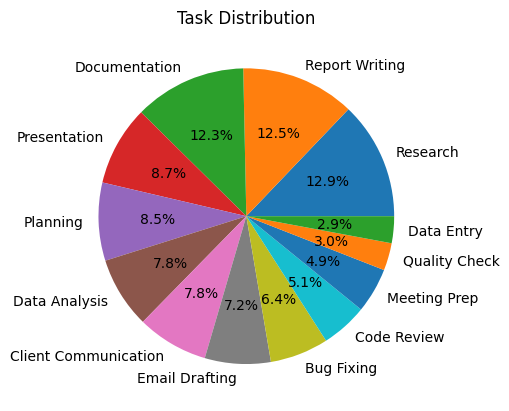

In [8]:
task_dist = tasks['task_type'].value_counts()

task_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title("Task Distribution")
plt.ylabel("")
plt.show()

### COST OVER TIME

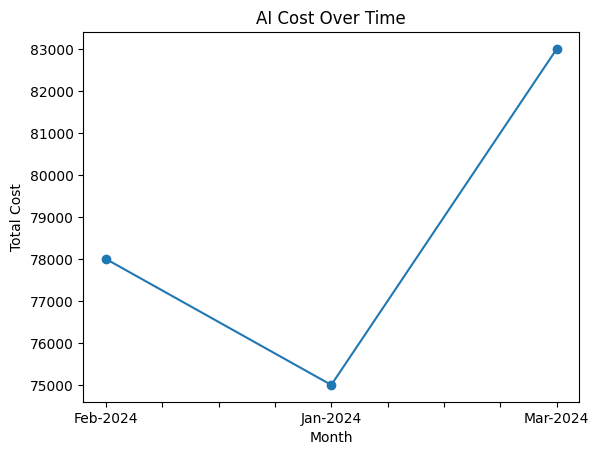

In [9]:
cost_trend = ai_cost.groupby('month')['total_cost'].sum()

cost_trend.plot(kind='line', marker='o')
plt.title("AI Cost Over Time")
plt.xlabel("Month")
plt.ylabel("Total Cost")
plt.xticks(rotation=360)
plt.show()

### COST VS VALUE

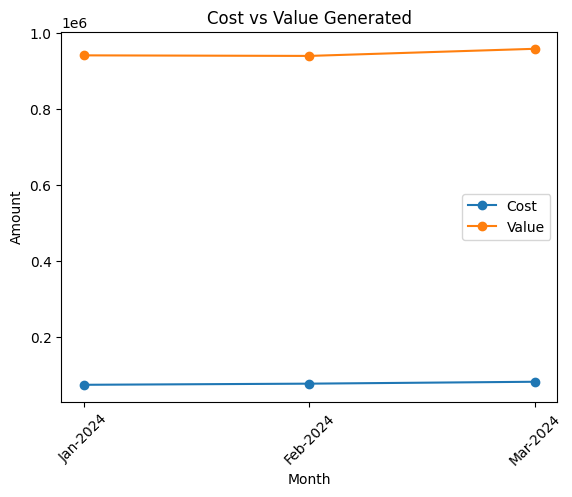

In [10]:
plt.plot(ai_cost['month'], ai_cost['total_cost'], label='Cost', marker='o')
plt.plot(ai_cost['month'], ai_cost['estimated_value_saved'], label='Value', marker='o')

plt.title("Cost vs Value Generated")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### DEPARTMENT ANALYSIS

In [22]:
merged = pd.merge(tasks, employees, on='employee_id')

In [23]:
# Drop duplicate department column from tasks
merged = merged.drop(columns=['department_x'])

# Rename correct column
merged = merged.rename(columns={'department_y': 'department'})

In [24]:
dept_perf = merged.groupby('department').agg({
    'actual_time_min': 'mean',
    'quality_score': 'mean'
}).reset_index()

print(dept_perf)

    department  actual_time_min  quality_score
0  Engineering       115.091111       7.693333
1      Finance       121.137778       7.244444
2           HR       121.093333       7.146667
3    Marketing       117.826667       7.426667
4      Product       117.083333       7.606667
5        Sales       127.440000       7.355556


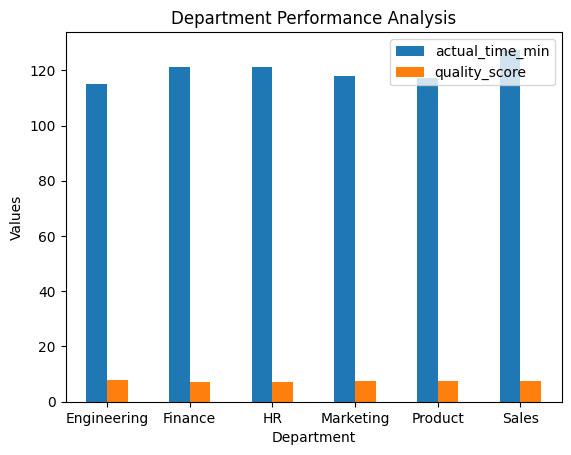

In [29]:
dept_perf.set_index('department').plot(kind='bar')

plt.title("Department Performance Analysis")
plt.xlabel("Department")
plt.ylabel("Values")
plt.xticks(rotation=360)
plt.show()